<a href="https://colab.research.google.com/github/AndresMontesDeOca/Analisis-de-Datos/blob/main/TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 2

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Load

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# You need to provide the actual file name from the dataset, e.g., 'AI_Jobs_Market_2025_2026_Salaries.csv'
# To find the exact file names, you can visit the Kaggle dataset page:
# https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries
file_path = "ai_jobs_market_2025_2026.csv" # Corrected file name based on directory listing

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alitaqishah/ai-jobs-market-2025-2026-salaries",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_496/3690229373.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


100%|██████████| 375k/375k [00:00<00:00, 1.72MB/s]


In [3]:
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


## EDA

In [4]:
data['job_category'].value_counts()

,count
job_category,
AI Engineering,736
Data Science,127
Governance,122
Robotics,74
Product,70
Business,62
Infrastructure,55
Architecture,52
ML Operations,51


In [5]:
data['job_title'].value_counts()

,count
job_title,
LLM Engineer,75
Robotics Engineer (AI),74
Prompt Engineer,71
Generative AI Engineer,71
AI Product Manager,70
Multimodal AI Engineer,67
Senior Data Scientist,66
AI Compliance Manager,66
Senior ML Engineer,64


In [6]:
data.isnull().sum()

,0
job_id,0
job_title,0
job_category,0
experience_level,0
years_of_experience,0
education_required,0
annual_salary_usd,0
salary_min_usd,0
salary_max_usd,0
city,0


In [10]:
data['job_id'].is_unique

True

In [11]:
data.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


<Axes: xlabel='years_of_experience'>

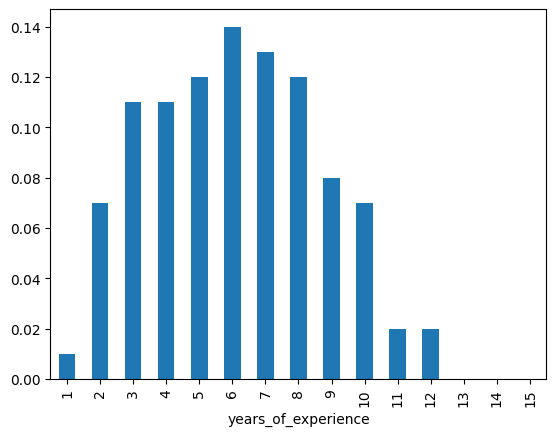

In [21]:
data['years_of_experience'].value_counts(normalize=True).round(2).sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

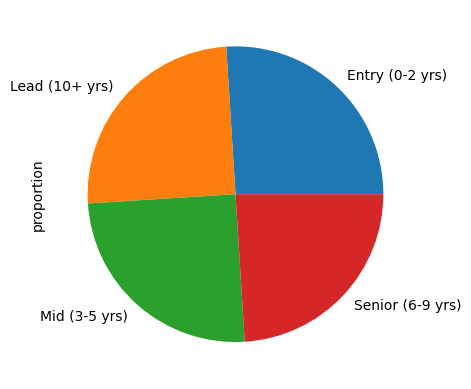

In [28]:
data['experience_level'].value_counts(normalize=True).round(2).sort_index().plot(kind='pie')

<Axes: xlabel='posting_month'>

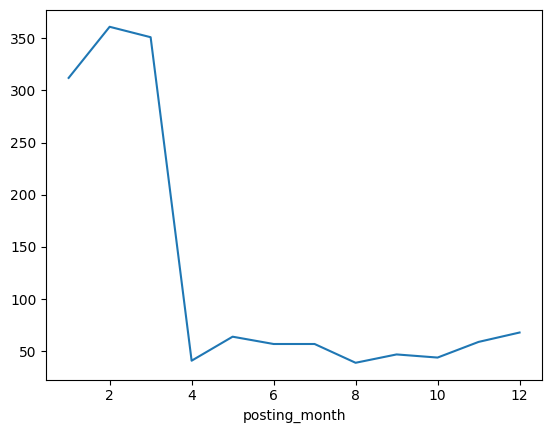

In [35]:
data['posting_month'].value_counts().sort_index().plot(kind='line')

/tmp/ipykernel_496/3493526129.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='annual_salary_usd', y='job_category',  palette='viridis', order=order, showfliers=True)


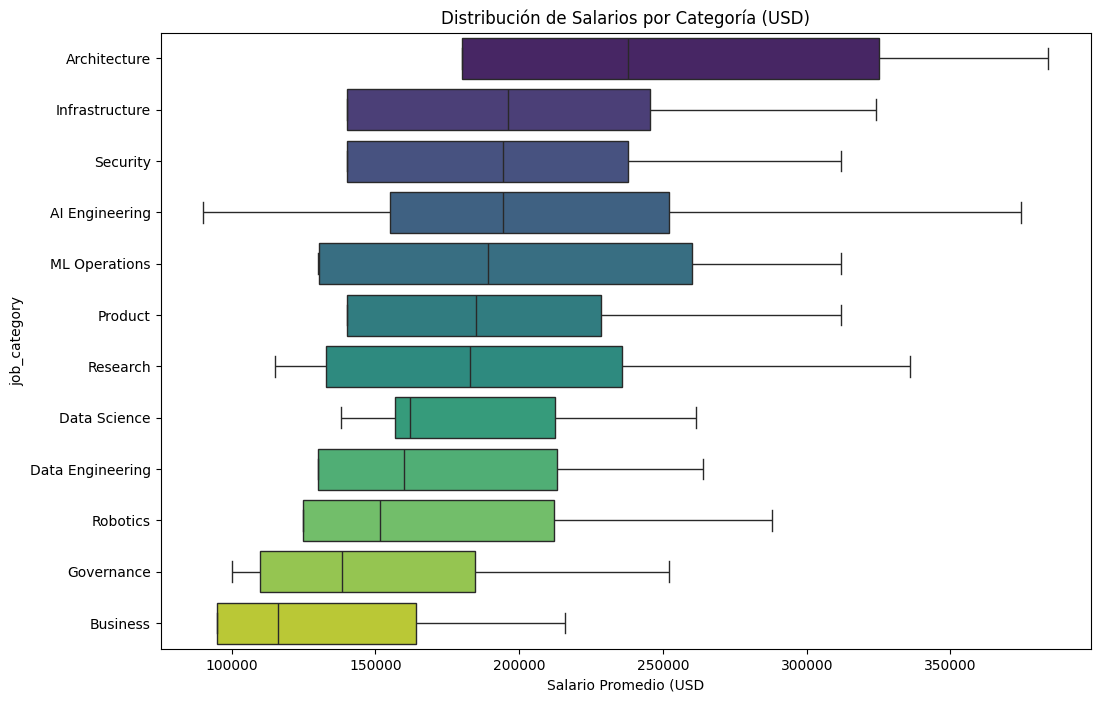

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# Ordenamos por salario promedio para que el gráfico sea más legible
order = data.groupby('job_category')['annual_salary_usd'].median().sort_values(ascending=False).index

sns.boxplot(data=data, x='annual_salary_usd', y='job_category',  palette='viridis', order=order, showfliers=True)
plt.xlabel('Salario Promedio (USD')
plt.title('Distribución de Salarios por Categoría (USD)')
plt.show()